# Inverse Flappy Bird Experiment

This notebook optimizes the wing flap angle parameter of a spacecraft model to achieve
target relative position offsets (height, cross-track, along-track) after 48 hours of propagation.

**Dynamics Model**: Monopole + J2 + SRP (via neural network proxy)

**Optimization**: JAX autodiff through the ODE solver with optax Adam optimizer

In [ ]:

from pathlib import Path
import base
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt

import nn
import physics
import utils
from integrator import solve

# Enable 64-bit precision
jax.config.update('jax_enable_x64', True)

# Paths
nn_weight_dir = Path(base.drive_path + 'nn_weights/bird')
trajectory_path = Path(base.drive_path + 'trajectories/gps06.csv')

In [9]:
# Spacecraft properties
sat_name = 'bird_fly'
sc_area = 100.0   # m^2
sc_mass = 1000.0  # kg

# Load neural network parameters
nn_params = nn.load_nn_parameters(nn_weight_dir / f'{sat_name}_parameters.bin')
nn_force_stats = nn.load_nn_parameters(nn_weight_dir / f'{sat_name}_force_stats.bin')
nn_ray_stats = nn.load_nn_parameters(nn_weight_dir / f'{sat_name}_ray_stats.bin')

# Convert to float64 for JAX precision
nn_params = tuple(jnp.asarray(p, dtype=jnp.float64) for p in nn_params)
nn_ray_stats = tuple(jnp.asarray(s, dtype=jnp.float64) for s in nn_ray_stats)
nn_force_stats = tuple(jnp.asarray(s, dtype=jnp.float64) for s in nn_force_stats)

print(f'Loaded NN for {sat_name}')
print(f'  Input stats shape: {nn_ray_stats[0].shape}')
print(f'  Output stats shape: {nn_force_stats[0].shape}')
print(f'  Network layers: {len(nn_params)}')

Loaded NN for bird_fly
  Input stats shape: (4,)
  Output stats shape: (3,)
  Network layers: 3


In [10]:
# Load reference trajectory
reference_trajectory = utils.load_trajectory(str(trajectory_path), limit=5)

# Simulation parameters
prop_time_hrs = 48
step_size_sec = 15
num_steps = int((prop_time_hrs * 3600) / step_size_sec)

# Time span
t0 = reference_trajectory.time[0]
t1 = t0 + (step_size_sec * num_steps)

# Initial conditions
start_position = reference_trajectory.position[0]
start_velocity = reference_trajectory.velocity[0]

# Conditions tuple: (moon_positions, sun_positions, reference_times)
conditions = (reference_trajectory.moon, reference_trajectory.sun, reference_trajectory.time)

print(f'Simulation: {prop_time_hrs} hours, {step_size_sec}s steps, {num_steps} total steps')
print(f'Initial position: {start_position}')
print(f'Initial velocity: {start_velocity}')

Simulation: 48 hours, 15s steps, 11520 total steps
Initial position: [13978258.8   22476723.321 -1873839.308]
Initial velocity: [-1715.16589  1341.69768  3208.66625]


In [11]:
def acceleration_model(position, time, factor, conditions):
    """
    Compute total acceleration: Monopole + J2 + 3BP (Moon & Sun) + SRP (via NN).
    
    Args:
        position: Spacecraft position in ECI [m]
        time: Current time [MJD seconds]
        factor: Wing flap angle parameter (optimized)
        conditions: Tuple of (moon_positions, sun_positions, reference_times)
    
    Returns:
        Total acceleration vector in ECI [m/s^2]
    """
    moon_positions, sun_positions, reference_times = conditions
    
    # Gravity (monopole)
    MU = 3.986004418e14
    r = jnp.linalg.norm(position)
    grav_acc = -MU * position / (r ** 3)
    
    # J2 perturbation
    x, y, z = position
    r2 = r * r
    z2 = z * z
    G = 6.67430e-11
    earth_mass = 5.972168494074286e24
    earth_radius = 6_378_137.0
    J2 = 1.08263e-3
    j2_factor = 1.5 * J2 * (G * earth_mass * earth_radius**2) / (r**5)
    ax = -x * (1.0 - 5.0 * z2 / r2) * j2_factor
    ay = -y * (1.0 - 5.0 * z2 / r2) * j2_factor
    az = -z * (3.0 - 5.0 * z2 / r2) * j2_factor
    j2_acc = jnp.array([ax, ay, az])
    
    # Get Moon and Sun positions at current time
    moon_position = utils.sample_moonsun_cubic(time, moon_positions, reference_times)
    sun_position = utils.sample_moonsun_cubic(time, sun_positions, reference_times)
    
    # Third-body perturbations
    moon_mass = 7.346e22
    sun_mass = 1.989e30
    moon3bp = physics.compute_third_body_acceleration(position, moon_position, moon_mass)
    sun3bp = physics.compute_third_body_acceleration(position, sun_position, sun_mass)
    
    # SRP via NN
    parameter = 1 * factor  # wing flap angle
    
    # Get sun direction in spacecraft body frame
    sun_lat, sun_lon = physics.sun_direction_in_sc_frame(position, sun_position)
    sun_direction_vector = utils.lat_lon_to_cart(sun_lat, sun_lon)
    
    # NN input: sun direction + parameter
    nn_input = jnp.append(sun_direction_vector, parameter)
    
    # Normalize input
    min_ray_stats, max_ray_stats = nn_ray_stats
    nn_input_whitened = (nn_input - min_ray_stats) / (max_ray_stats - min_ray_stats)
    
    # Forward pass through NN
    neural_force_whitened = nn.mlp(nn_input_whitened, nn_params)
    
    # Denormalize output
    neural_force_denormalized = nn.unwhiten(neural_force_whitened, nn_force_stats)
    
    # Scale by area/mass ratio
    neural_force_denormalized = neural_force_denormalized * sc_area
    neural_force_denormalized = neural_force_denormalized / sc_mass
    
    # Rotate from body frame to inertial frame
    x_sc_cart, y_sc_cart, z_sc_cart = physics.sc_attitude(position, sun_position)
    cartesian_sc_att = jnp.stack([x_sc_cart, y_sc_cart, z_sc_cart], axis=1)
    neural_acc_inertial = cartesian_sc_att @ neural_force_denormalized
    
    # Total acceleration
    tot_acc = grav_acc + neural_acc_inertial + moon3bp + sun3bp + j2_acc
    return tot_acc

In [12]:
# Compute reference final position (with wing_angle = 1.0)
def state_derivative_ref(state, time, conditions):
    """State derivative for reference trajectory (wing_angle = 1)."""
    position, velocity = state[:3], state[3:]
    acceleration = acceleration_model(position, time, 1.0, conditions)
    return jnp.concatenate([velocity, acceleration])

z0_flat = jnp.concatenate([start_position, start_velocity])
_, ref_states = solve(z0_flat, t0, t1, state_derivative_ref, conditions, step_count=num_steps)
ref_pos_plus1 = ref_states[-1, :3]

print(f'Reference final position: {ref_pos_plus1}')

Reference final position: [13176949.7733126  23032498.06644431  -373215.36214307]


In [13]:
def position_loss(state):
    """
    Compute loss based on height, cross-track, and along-track distances
    relative to reference position.
    
    Target values:
        - Height (radial): 10 m
        - Cross-track: 6 m  
        - Along-track: 60 m
    """
    pos, vel = state[0], state[1]
    
    # Compute the height (radial) unit vector
    height_vector = pos / jnp.linalg.norm(pos)
    
    # Compute the cross-track unit vector (perpendicular to orbit plane)
    cross_track_vector = jnp.cross(vel, height_vector)
    cross_track_unit_vector = cross_track_vector / jnp.linalg.norm(cross_track_vector)
    
    # Position difference relative to reference
    pos_diff = pos - ref_pos_plus1
    
    # Compute distances in each direction
    cross_track_distance = jnp.abs(jnp.dot(pos_diff, cross_track_unit_vector))
    height_distance = jnp.abs(jnp.dot(pos_diff, height_vector))
    
    along_track_unit_vector = jnp.cross(cross_track_unit_vector, height_vector)
    along_track_distance = jnp.abs(jnp.dot(pos_diff, along_track_unit_vector))
    
    # Target values
    target_height = 10.0
    target_cross_track = 6.0
    target_along_track = 60.0
    
    # Compute the relative loss as percentage difference squared
    height_loss = ((height_distance - target_height) / target_height) ** 2
    cross_track_loss = ((cross_track_distance - target_cross_track) / target_cross_track) ** 2
    along_track_loss = ((along_track_distance - target_along_track) / target_along_track) ** 2
    
    return height_loss + cross_track_loss + along_track_loss

In [14]:
def total_loss(wing_angle):
    """
    End-to-end loss from wing angle parameter to trajectory outcome.
    
    Propagates the orbit for 48 hours and computes loss on final state.
    """
    z0 = jnp.array([start_position, start_velocity])
    
    def ode_fn(z, t, param, conds):
        pos, vel = z[0], z[1]
        acc = acceleration_model(pos, t, param, conds)
        return jnp.array([vel, acc])
    
    _, states = solve(z0, t0, t1, ode_fn, wing_angle, conditions, step_count=num_steps)
    final_state = states[-1]
    return position_loss(final_state)

# JIT compile the loss and gradient computation
loss_and_grad = jax.jit(jax.value_and_grad(total_loss))

# Test the loss function
test_loss, test_grad = loss_and_grad(0.5)
print(f'Test loss at wing_angle=0.5: {test_loss:.6f}')
print(f'Test gradient: {test_grad:.6f}')

Test loss at wing_angle=0.5: 2.849528
Test gradient: 0.294675


In [15]:
# Optimization setup
max_iters = 10_000
log_every = 20

# Cosine decay learning rate schedule
schedule = optax.cosine_decay_schedule(
    init_value=0.05,
    decay_steps=max_iters,
    alpha=0.01
)

# Optimizer with gradient clipping
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=schedule)
)

# Initialize
param_init_guess = 0.5
optimized_parameter = jnp.float64(param_init_guess)
opt_state = optimizer.init(optimized_parameter)

# Tracking
losses = []
params = []
diffs = []
true_value = 1.0  # Expected optimal wing angle

print(f'Starting optimization from wing_angle = {param_init_guess}')
print(f'Target wing_angle = {true_value}')

Starting optimization from wing_angle = 0.5
Target wing_angle = 1.0


In [16]:
# Run optimization
for i in range(max_iters):
    # Compute loss and gradient
    loss_val, g = loss_and_grad(optimized_parameter)
    
    # Update parameter
    updates, opt_state = optimizer.update(g, opt_state)
    optimized_parameter = optax.apply_updates(optimized_parameter, updates)
    
    # Track progress
    percent_diff = (optimized_parameter - true_value) / true_value * 100
    losses.append(float(loss_val))
    params.append(float(optimized_parameter))
    diffs.append(float(percent_diff))
    
    # Log progress
    if i % log_every == 0:
        print(f'iter {i:5d}: loss={loss_val:.6f}, param={optimized_parameter:.6f}, '
              f'diff={percent_diff:+.2f}%, grad={g:.6f}')

print(f'\nOptimization complete!')
print(f'Final wing_angle = {optimized_parameter:.6f}')
print(f'Final loss = {losses[-1]:.6f}')
print(f'Error from target = {diffs[-1]:+.2f}%')

iter     0: loss=2.849528, param=0.450000, diff=-55.00%, grad=0.294675
iter    20: loss=2.374239, param=-0.501431, diff=-150.14%, grad=-27.825190
iter    40: loss=1.401671, param=-0.423031, diff=-142.30%, grad=-11.172251
iter    60: loss=1.270718, param=-0.419057, diff=-141.91%, grad=-5.976590
iter    80: loss=1.222571, param=-0.401753, diff=-140.18%, grad=-1.650878
iter   100: loss=1.218877, param=-0.403193, diff=-140.32%, grad=-0.427083
iter   120: loss=1.218613, param=-0.401454, diff=-140.15%, grad=0.009762
iter   140: loss=1.218622, param=-0.402063, diff=-140.21%, grad=-0.079871
iter   160: loss=1.218614, param=-0.402047, diff=-140.20%, grad=-0.030014
iter   180: loss=1.218613, param=-0.402041, diff=-140.20%, grad=0.003518
iter   200: loss=1.218613, param=-0.402061, diff=-140.21%, grad=-0.003865
iter   220: loss=1.218613, param=-0.402063, diff=-140.21%, grad=-0.001239
iter   240: loss=1.218613, param=-0.402061, diff=-140.21%, grad=-0.000232
iter   260: loss=1.218613, param=-0.40206

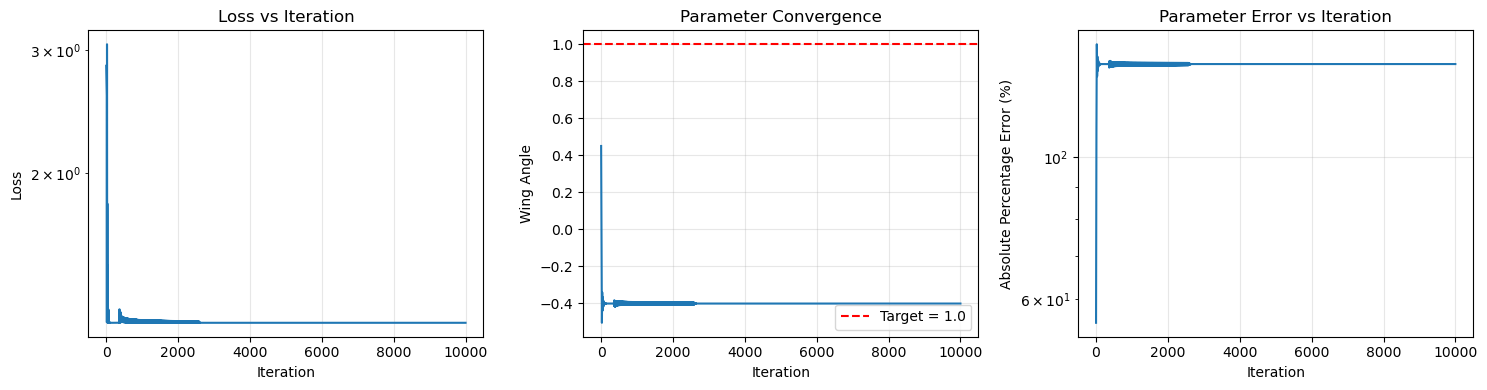

In [17]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(losses)
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss vs Iteration')
axes[0].grid(True, alpha=0.3)

# Parameter convergence
axes[1].plot(params)
axes[1].axhline(y=true_value, color='r', linestyle='--', label=f'Target = {true_value}')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Wing Angle')
axes[1].set_title('Parameter Convergence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Percentage difference
axes[2].plot(np.abs(diffs))
axes[2].set_yscale('log')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Absolute Percentage Error (%)')
axes[2].set_title('Parameter Error vs Iteration')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Final verification: compare trajectories
def propagate_with_angle(wing_angle):
    """Propagate trajectory with given wing angle."""
    z0 = jnp.array([start_position, start_velocity])
    
    def ode_fn(z, t, param, conds):
        pos, vel = z[0], z[1]
        acc = acceleration_model(pos, t, param, conds)
        return jnp.array([vel, acc])
    
    ts, states = solve(z0, t0, t1, ode_fn, wing_angle, conditions, step_count=num_steps)
    return ts, states

# Propagate with initial guess and optimized value
_, states_init = propagate_with_angle(param_init_guess)
_, states_opt = propagate_with_angle(optimized_parameter)
_, states_true = propagate_with_angle(true_value)

# Compute final position differences
final_init = states_init[-1, 0]
final_opt = states_opt[-1, 0]
final_true = states_true[-1, 0]

print('Final position comparison:')
print(f'  Initial guess (0.5): {jnp.linalg.norm(final_init - ref_pos_plus1):.2f} m from reference')
print(f'  Optimized ({optimized_parameter:.4f}): {jnp.linalg.norm(final_opt - ref_pos_plus1):.2f} m from reference')
print(f'  True value (1.0): {jnp.linalg.norm(final_true - ref_pos_plus1):.2f} m from reference')

Final position comparison:
  Initial guess (0.5): 3.15 m from reference
  Optimized (-0.4021): 74.59 m from reference
  True value (1.0): 0.00 m from reference
